# 01  Ultra-rare, length-normalized regulatory variance predicts gene constraint and purifying selection

Here we are introducing new AF metrices that we added 


## Variant Count Metrics

### **n_variants**
- **Type:** Integer
- **Description:** Total number of unique variants in this gene
- **Calculation:** Count of unique variant_id after deduplication by highest absolute effect

### **n_variants_common**
- **Type:** Integer
- **Description:** Number of common variants (AF ≥ 0.05)
- **Calculation:** Count where AF ≥ 0.05

### **n_variants_rare**
- **Type:** Integer
- **Description:** Number of rare variants (AF < 0.05)
- **Calculation:** Count where AF < 0.05

### **n_variants_common_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF ≥ 0.05
- **Calculation:** Count where perm_AF ≥ 0.05
- **Note:** Only present when permuted AFs are available

### **n_variants_rare_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF < 0.05
- **Calculation:** Count where perm_AF < 0.05
- **Note:** Only present when permuted AFs are available

### **variants_per_kb**
- **Type:** Float
- **Description:** Variant density normalized by genomic length
- **Calculation:** n_variants / (genomic_length / 1000)

## Genetic Variance (Vg) Metrics

### **vg_predicted**
- **Type:** Float
- **Description:** Total predicted genetic variance for this gene
- **Formula:** Σ[2 × AF × (1 - AF) × β²] across all variants
- **Note:** Primary Vg metric using observed allele frequencies

### **vg_predicted_perm**
- **Type:** Float
- **Description:** Total predicted genetic variance using permuted allele frequencies
- **Formula:** Σ[2 × perm_AF × (1 - perm_AF) × β²]
- **Note:** Used as null expectation for selection analyses

### **vg_common**
- **Type:** Float
- **Description:** Genetic variance contribution from common variants (AF ≥ 0.05)
- **Calculation:** Sum of vg_contribution where AF ≥ 0.05

### **vg_rare**
- **Type:** Float
- **Description:** Genetic variance contribution from rare variants (AF < 0.05)
- **Calculation:** Sum of vg_contribution where AF < 0.05

### **vg_common_perm**
- **Type:** Float
- **Description:** Genetic variance from common variants using permuted AFs
- **Note:** Only present when permuted AFs are available

### **vg_rare_perm**
- **Type:** Float
- **Description:** Genetic variance from rare variants using permuted AFs
- **Note:** Only present when permuted AFs are available


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_Promoter_exploring'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [4]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [5]:
NOTEBOOK_NAME = '01_AF_cutoff_distribution'

SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']
PLOT_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth',
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
}

palette = {
    'background': SOURCE_PALETTE['background'],
    'background_null': SOURCE_PALETTE['background_null'],
    'clingen': SOURCE_PALETTE['clingen'],
    'clingen_null': SOURCE_PALETTE['clingen_null'],
}

REGION_COLS = {
    'promoter_core': 'Promoter (TSS±200bp)',
    'proximal_upstream': 'Proximal upstream (-200 bp to -2 kb)',
    'distal_upstream': 'Distal upstream (-2 kb to -10 kb)',
    'down_proximal': 'Proximal downstream (+200 bp to +2 kb)',
    'down_distal': 'Distal downstream (+2 kb to +10 kb)',
}

required_cols = [
    'source', 'gene_symbol',
    'vg_predicted', 'vg_predicted_perm',
    'vg_common', 'vg_common_perm',
    'vg_rare', 'vg_rare_perm',
    'n_variants_common', 'n_variants_rare', 'variants_per_kb',
    'vg_promoter_core', 'vg_promoter_core_perm',
    'vg_proximal_upstream', 'vg_proximal_upstream_perm',
    'vg_distal_upstream', 'vg_distal_upstream_perm',
    'vg_down_proximal', 'vg_down_proximal_perm',
    'vg_down_distal', 'vg_down_distal_perm',
]

all_genes = pl.concat([df_real, df_synth], how='diagonal_relaxed')
missing_cols = [c for c in required_cols if c not in all_genes.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

is_synth = pl.col('source').str.contains('null')

plot_df = (
    all_genes
    .select(required_cols)
    .with_columns([
        pl.when(is_synth).then(pl.col('vg_predicted_perm')).otherwise(pl.col('vg_predicted')).alias('vg_total_for_plot'),
        pl.when(is_synth).then(pl.col('vg_common_perm')).otherwise(pl.col('vg_common')).alias('vg_common_for_plot'),
        pl.when(is_synth).then(pl.col('vg_rare_perm')).otherwise(pl.col('vg_rare')).alias('vg_rare_for_plot'),
        pl.when(is_synth).then(pl.col('vg_promoter_core_perm')).otherwise(pl.col('vg_promoter_core')).alias('vg_region_promoter_core'),
        pl.when(is_synth).then(pl.col('vg_proximal_upstream_perm')).otherwise(pl.col('vg_proximal_upstream')).alias('vg_region_proximal_upstream'),
        pl.when(is_synth).then(pl.col('vg_distal_upstream_perm')).otherwise(pl.col('vg_distal_upstream')).alias('vg_region_distal_upstream'),
        pl.when(is_synth).then(pl.col('vg_down_proximal_perm')).otherwise(pl.col('vg_down_proximal')).alias('vg_region_down_proximal'),
        pl.when(is_synth).then(pl.col('vg_down_distal_perm')).otherwise(pl.col('vg_down_distal')).alias('vg_region_down_distal'),
    ])
    .with_columns([
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_rare_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_rare_fraction')
    ])
    .filter(pl.col('source').is_in(SOURCE_ORDER))
    .drop_nulls(subset=['source', 'vg_total_for_plot'])
    .to_pandas()
)

plot_df['source_label'] = plot_df['source'].map(PLOT_LABELS)
source_label_order = [PLOT_LABELS[s] for s in SOURCE_ORDER]
palette_by_label = {PLOT_LABELS[s]: palette[s] for s in SOURCE_ORDER}

def p_to_stars(p_value):
    if p_value < 1e-4:
        return '****'
    if p_value < 1e-3:
        return '***'
    if p_value < 1e-2:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

def add_sig_brackets(ax, data, x_col, y_col, order, pairs):
    y_max = np.nanmax(data[y_col].values)
    y_min = np.nanmin(data[y_col].values[data[y_col].values > 0]) if (data[y_col] > 0).any() else 1e-8
    use_log = ax.get_yscale() == 'log'
    level = y_max * 1.30 if use_log else y_max * 1.05
    step = 1.45 if use_log else (y_max - y_min) * 0.09

    for idx, (group_a, group_b) in enumerate(pairs):
        a = data.loc[data[x_col] == group_a, y_col].dropna()
        b = data.loc[data[x_col] == group_b, y_col].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        x1, x2 = order.index(group_a), order.index(group_b)
        y = level * (step ** idx) if use_log else level + idx * step

        if use_log:
            y_low = y / 1.05
        else:
            y_low = y - (y_max - y_min) * 0.01

        ax.plot([x1, x1, x2, x2], [y_low, y, y, y_low], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y * (1.04 if use_log else 1.0), p_to_stars(p_val),
                ha='center', va='bottom', fontsize=10, color='black')

def annotate_medians(ax, data, x_col, y_col, order, fmt='{:.2e}', text_color='white', y_offset_factor=1.03):
    medians = data.groupby(x_col, dropna=False)[y_col].median()
    for idx, category in enumerate(order):
        if category not in medians.index:
            continue
        median_val = medians.loc[category]
        if pd.isna(median_val):
            continue
        label_y = median_val * y_offset_factor if ax.get_yscale() == 'log' else median_val
        ax.text(idx, label_y, fmt.format(median_val), ha='center', va='bottom', fontsize=8,
                color=text_color, fontweight='bold', zorder=6)

def set_violin_alpha(ax, alpha):
    for coll in ax.collections:
        coll.set_alpha(alpha)

print('Config and shared data prepared for AF cutoff plots.')

Config and shared data prepared for AF cutoff plots.


# 1. VG distribution between datasets

[save_plot] Saved: figuree_AF_Cutoff_VgPredicted_Boxplot_WithSignificance_20022026_1128.pdf
[save_plot] Saved: figuree_AF_Cutoff_VgPredicted_Boxplot_WithSignificance_20022026_1128.svg


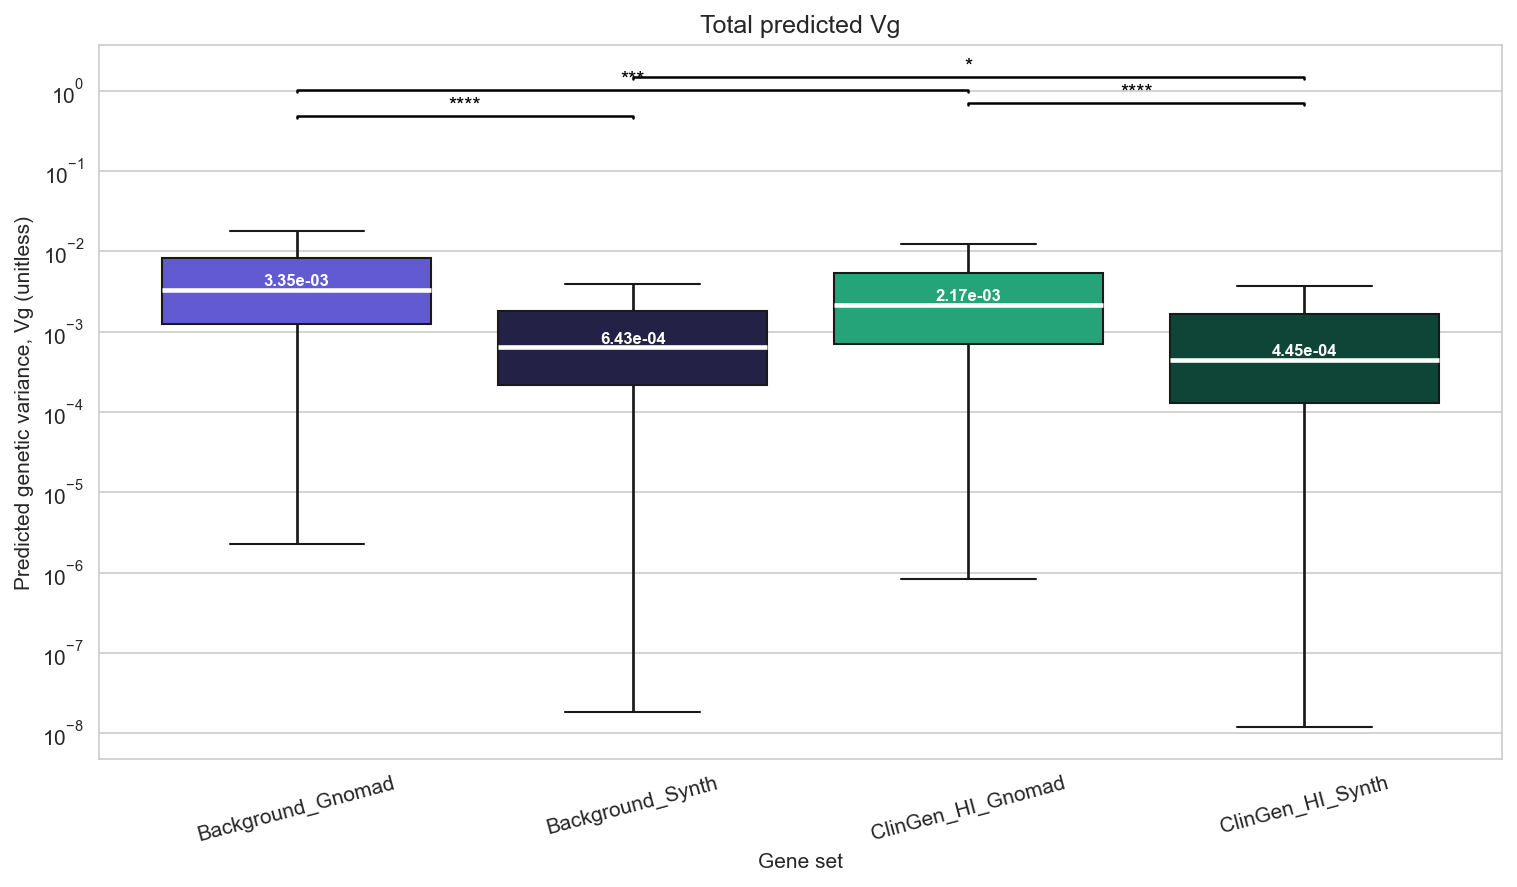

In [6]:
with autosave('AF_Cutoff_VgPredicted_Boxplot_WithSignificance'):
    fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
    sns.boxplot(
        data=plot_df,
        x='source_label',
        y='vg_total_for_plot',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        dodge=False,
        legend=False,
        showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.2},
        whiskerprops={'linewidth': 1.3},
        ax=ax,
    )
    ax.set_yscale('log')
    annotate_medians(ax, plot_df, 'source_label', 'vg_total_for_plot', source_label_order, text_color='white')
    add_sig_brackets(
        ax,
        plot_df,
        x_col='source_label',
        y_col='vg_total_for_plot',
        order=source_label_order,
        pairs=[
            ('Background_Gnomad', 'Background_Synth'),
            ('ClinGen_HI_Gnomad', 'ClinGen_HI_Synth'),
            ('Background_Gnomad', 'ClinGen_HI_Gnomad'),
            ('Background_Synth', 'ClinGen_HI_Synth'),
        ],
    )
    ax.set_xlabel('Gene set', fontsize=10)
    ax.set_ylabel('Predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Total predicted Vg')
    ax.tick_params(axis='x', rotation=15)
    

# 1. AF cutoffs - rare vs common predicted VG

[save_plot] Saved: figuree_AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette_20022026_1128.pdf
[save_plot] Saved: figuree_AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette_20022026_1128.svg


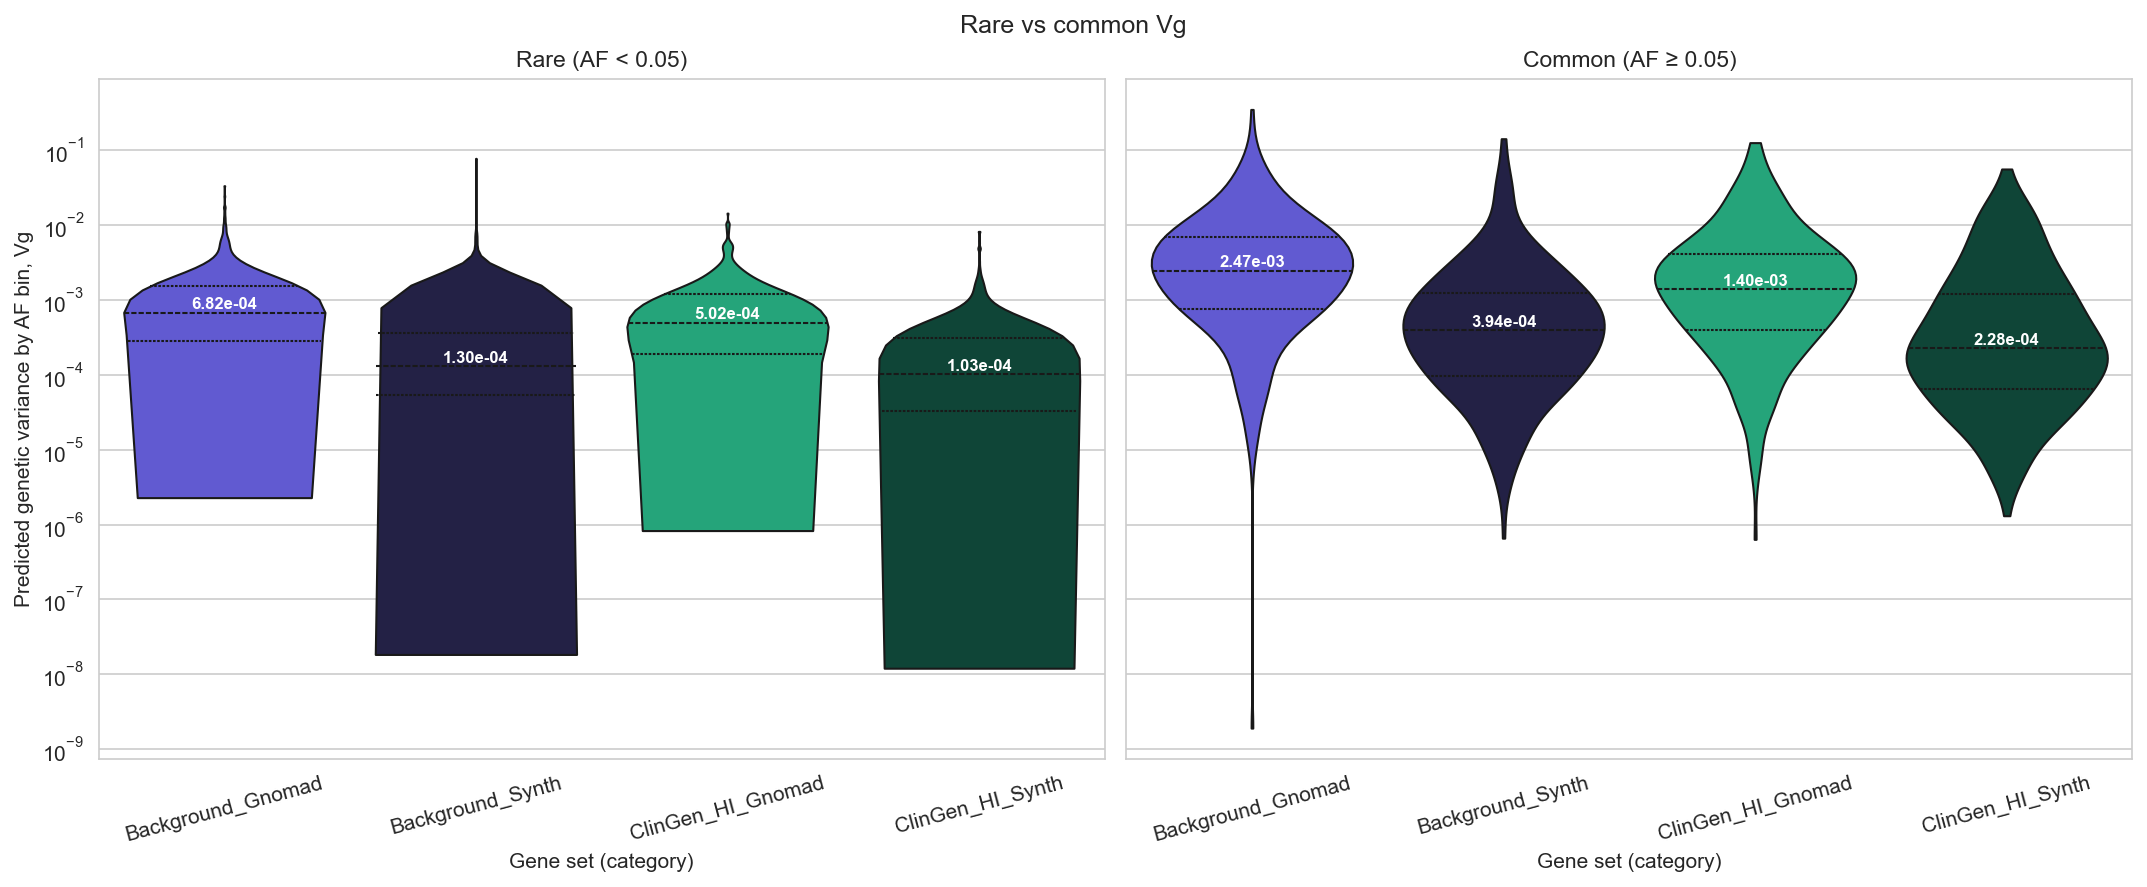

In [7]:
vg_long = plot_df.melt(
    id_vars=['source', 'source_label'],
    value_vars=['vg_rare_for_plot', 'vg_common_for_plot'],
    var_name='af_group',
    value_name='vg_component',
)
vg_long['af_group'] = vg_long['af_group'].map({
    'vg_rare_for_plot': 'Rare (AF < 0.05)',
    'vg_common_for_plot': 'Common (AF ≥ 0.05)',
})
vg_long = vg_long[vg_long['vg_component'] > 0].copy()
af_order = ['Rare (AF < 0.05)', 'Common (AF ≥ 0.05)']

with autosave('AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette'):
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.8), sharey=True, constrained_layout=True)

    for ax, af_class in zip(axes, af_order):
        sub = vg_long[vg_long['af_group'] == af_class]
        sns.violinplot(
            data=sub,
            x='source_label',
            y='vg_component',
            hue='source_label',
            order=source_label_order,
            hue_order=source_label_order,
            palette=palette_by_label,
            dodge=False,
            legend=False,
            inner='quart',
            cut=0,
            bw_adjust=1.0,
            linewidth=1.0,
            ax=ax,
        )
        ax.set_yscale('log')
        annotate_medians(ax, sub, 'source_label', 'vg_component', source_label_order, text_color='white')
        ax.set_title(af_class, fontsize=11)
        ax.set_xlabel('Gene set (category)', fontsize=10)
        ax.tick_params(axis='x', rotation=15)

    axes[0].set_ylabel('Predicted genetic variance by AF bin, Vg', fontsize=10)
    axes[1].set_ylabel('')
    fig.suptitle('Rare vs common Vg', fontsize=12)

# 1c. Stacked Vg Contribution - Absolute Mean Values

[save_plot] Saved: figuree_AF_Cutoff_Stacked_RareCommon_MeanVg_20022026_1128.pdf
[save_plot] Saved: figuree_AF_Cutoff_Stacked_RareCommon_MeanVg_20022026_1128.svg


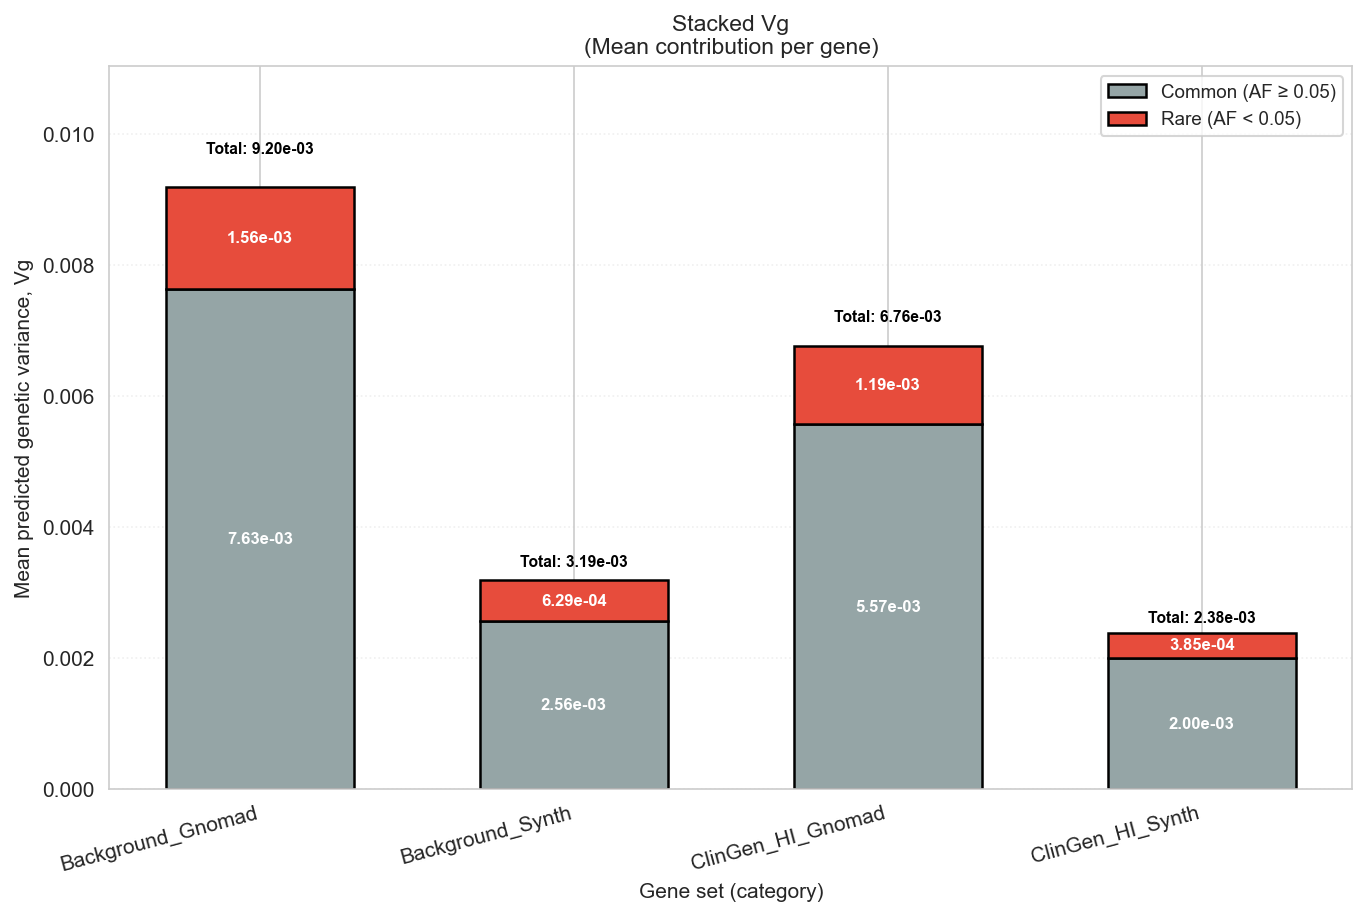

In [8]:
# Plot 3: Stacked Vg Contribution - Mean values for rare and common
stacked_df = plot_df.groupby('source_label', as_index=False).agg({
    'vg_common_for_plot': 'mean',
    'vg_rare_for_plot': 'mean',
    'vg_total_for_plot': 'mean',
})

with autosave('AF_Cutoff_Stacked_RareCommon_MeanVg'):
    fig, ax = plt.subplots(figsize=(9.0, 6.0), constrained_layout=True)
    
    x_positions = np.arange(len(source_label_order))
    width = 0.6
    
    # Stacked bars: common on bottom, rare on top
    bars_common = ax.bar(
        x_positions,
        stacked_df.set_index('source_label').loc[source_label_order, 'vg_common_for_plot'],
        width,
        label='Common (AF ≥ 0.05)',
        color='#95a5a6',
        edgecolor='black',
        linewidth=1.2,
    )
    
    bars_rare = ax.bar(
        x_positions,
        stacked_df.set_index('source_label').loc[source_label_order, 'vg_rare_for_plot'],
        width,
        bottom=stacked_df.set_index('source_label').loc[source_label_order, 'vg_common_for_plot'],
        label='Rare (AF < 0.05)',
        color='#e74c3c',
        edgecolor='black',
        linewidth=1.2,
    )
    
    # Add value labels on each segment
    for i, source in enumerate(source_label_order):
        row = stacked_df[stacked_df['source_label'] == source].iloc[0]
        common_val = row['vg_common_for_plot']
        rare_val = row['vg_rare_for_plot']
        total_val = row['vg_total_for_plot']
        
        # Label for common segment (middle of common bar)
        ax.text(i, common_val / 2, f'{common_val:.2e}',
               ha='center', va='center', fontsize=8, color='white', weight='bold')
        
        # Label for rare segment (middle of rare bar)
        ax.text(i, common_val + rare_val / 2, f'{rare_val:.2e}',
               ha='center', va='center', fontsize=8, color='white', weight='bold')
        
        # Total on top
        ax.text(i, total_val + total_val * 0.05, f'Total: {total_val:.2e}',
               ha='center', va='bottom', fontsize=7.5, color='black', weight='bold')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(source_label_order, rotation=15, ha='right')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Mean predicted genetic variance, Vg', fontsize=10)
    ax.set_title('Stacked Vg\n(Mean contribution per gene)', fontsize=11)
    ax.legend(loc='upper right', frameon=True, fontsize=9)
    ax.set_ylim(0, stacked_df['vg_total_for_plot'].max() * 1.2)
    ax.grid(axis='y', alpha=0.3, linestyle=':')

# 1b. The "Share" of Variance - Proportion from Common Variants

Calculate prop_common = vg_common / vg_predicted for each gene.

[save_plot] Saved: figuree_AF_Cutoff_CommonVariantShare_Violin_20022026_1128.pdf
[save_plot] Saved: figuree_AF_Cutoff_CommonVariantShare_Violin_20022026_1128.svg
Plot: Common variant share complete.


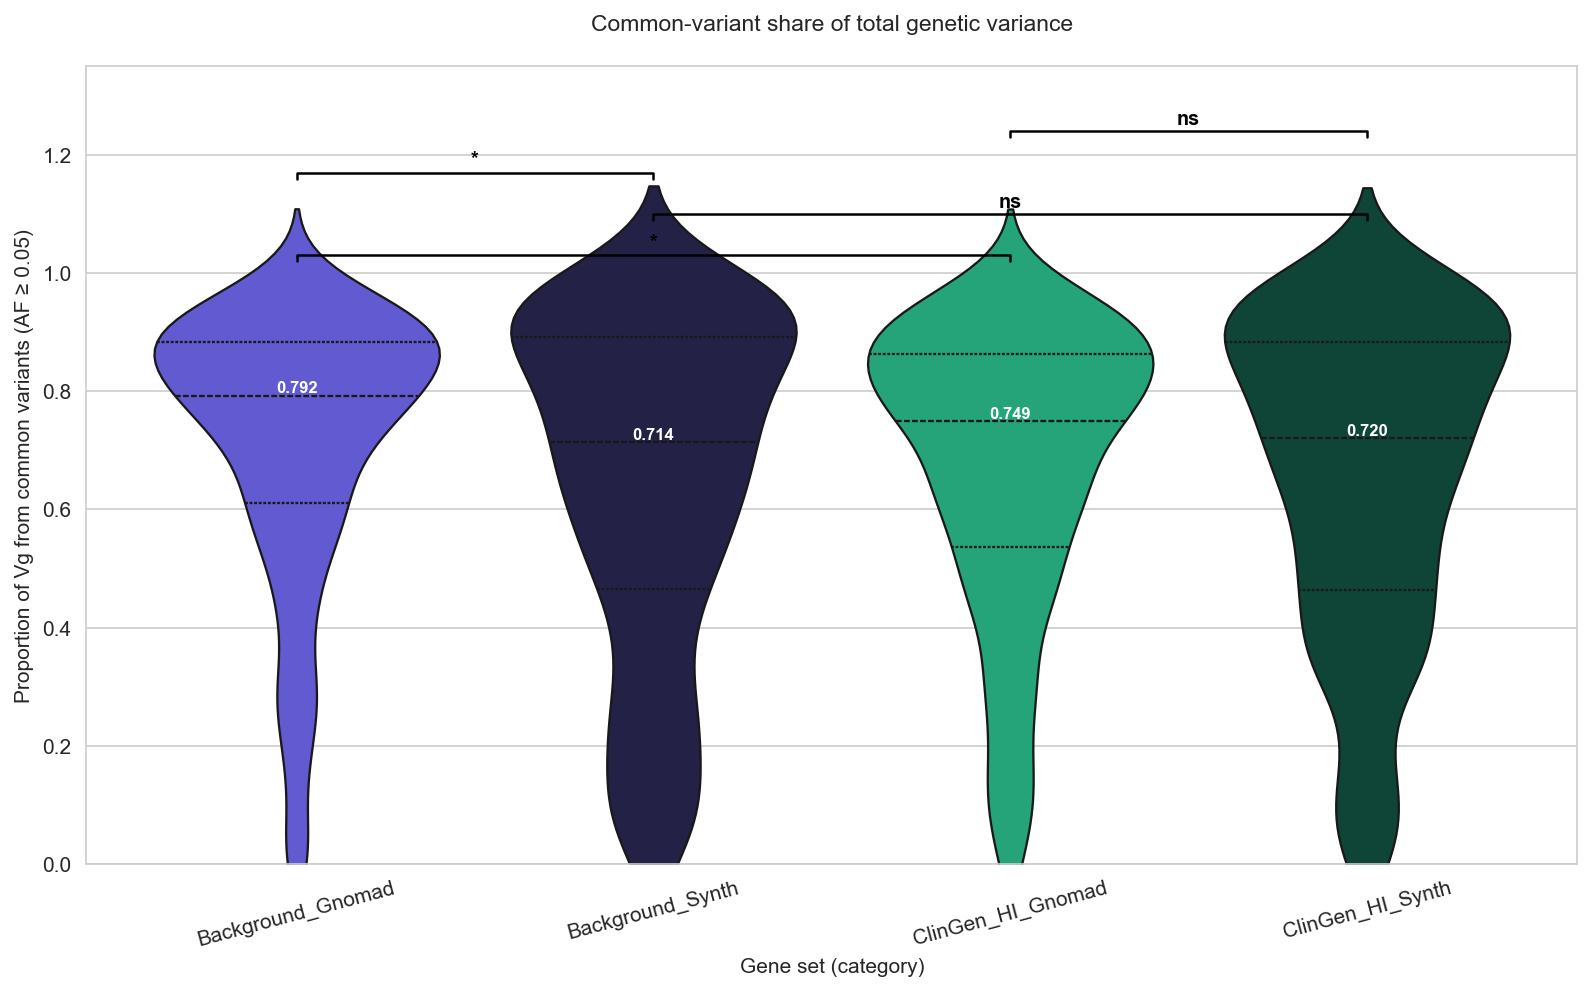

In [9]:
# Calculate vg_common_fraction
if 'vg_common_fraction' not in plot_df.columns:
    plot_df['vg_common_fraction'] = np.where(
        plot_df['vg_total_for_plot'] > 0,
        plot_df['vg_common_for_plot'] / plot_df['vg_total_for_plot'],
        np.nan
    )

share_df = plot_df[plot_df['vg_common_fraction'].notna()].copy()

with autosave('AF_Cutoff_CommonVariantShare_Violin'):
    fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
    
    sns.violinplot(
        data=share_df,
        x='source_label',
        y='vg_common_fraction',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        dodge=False,
        legend=False,
        inner='quart',
        cut=2,
        bw_adjust=0.85,
        linewidth=1.1,
        ax=ax,
    )
    
    # Add median annotations
    annotate_medians(ax, share_df, 'source_label', 'vg_common_fraction', 
                    source_label_order, fmt='{:.3f}', text_color='white', y_offset_factor=1.0)
    
    # Manual significance brackets for better control on linear scale
    y_data_max = share_df['vg_common_fraction'].max()
    bracket_start = 1.03
    bracket_step = 0.07
    
    pairs_to_test = [
        ('Background_Gnomad', 'ClinGen_HI_Gnomad', 0),
        ('Background_Synth', 'ClinGen_HI_Synth', 1),
        ('Background_Gnomad', 'Background_Synth', 2),
        ('ClinGen_HI_Gnomad', 'ClinGen_HI_Synth', 3),
    ]
    
    for group_a, group_b, level in pairs_to_test:
        a = share_df.loc[share_df['source_label'] == group_a, 'vg_common_fraction'].dropna()
        b = share_df.loc[share_df['source_label'] == group_b, 'vg_common_fraction'].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        
        x1 = source_label_order.index(group_a)
        x2 = source_label_order.index(group_b)
        y = bracket_start + level * bracket_step
        y_low = y - 0.01
        
        ax.plot([x1, x1, x2, x2], [y_low, y, y, y_low], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y + 0.005, p_to_stars(p_val),
                ha='center', va='bottom', fontsize=9.5, color='black', weight='bold')
    
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Proportion of Vg from common variants (AF ≥ 0.05)', fontsize=10)
    ax.set_title('Common-variant share of total genetic variance\n', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, 1.35)

print('Plot: Common variant share complete.')

Common variants (gray) dominate the absolute contribution to mean Vg
Background_Gnomad: 7.29e-03 (common) vs 1.47e-03 (rare) → ~83% common
ClinGen_HI_Gnomad: 5.42e-03 (common) vs 1.15e-03 (rare) → ~82% common


"Common variants contribute substantially to total genetic variance in absolute terms. However, when we zoom in on the PROPORTION (violin plot), we see that ClinGen haploinsufficient genes have a significantly smaller share from common variants - evolution has depleted common regulatory variation in these essential genes through purifying selection."

Here we confirm that ClinGen Haploinsufficient genes are depleted of common regulatory variation. Their total genetic variance is disproportionately driven by rare and ultra-rare variants compared to background genes.

# 2. Regional Vg summary

[save_plot] Saved: figuree_AF_Cutoff_Regional_Simplified_Boxplot_20022026_1128.pdf
[save_plot] Saved: figuree_AF_Cutoff_Regional_Simplified_Boxplot_20022026_1128.svg


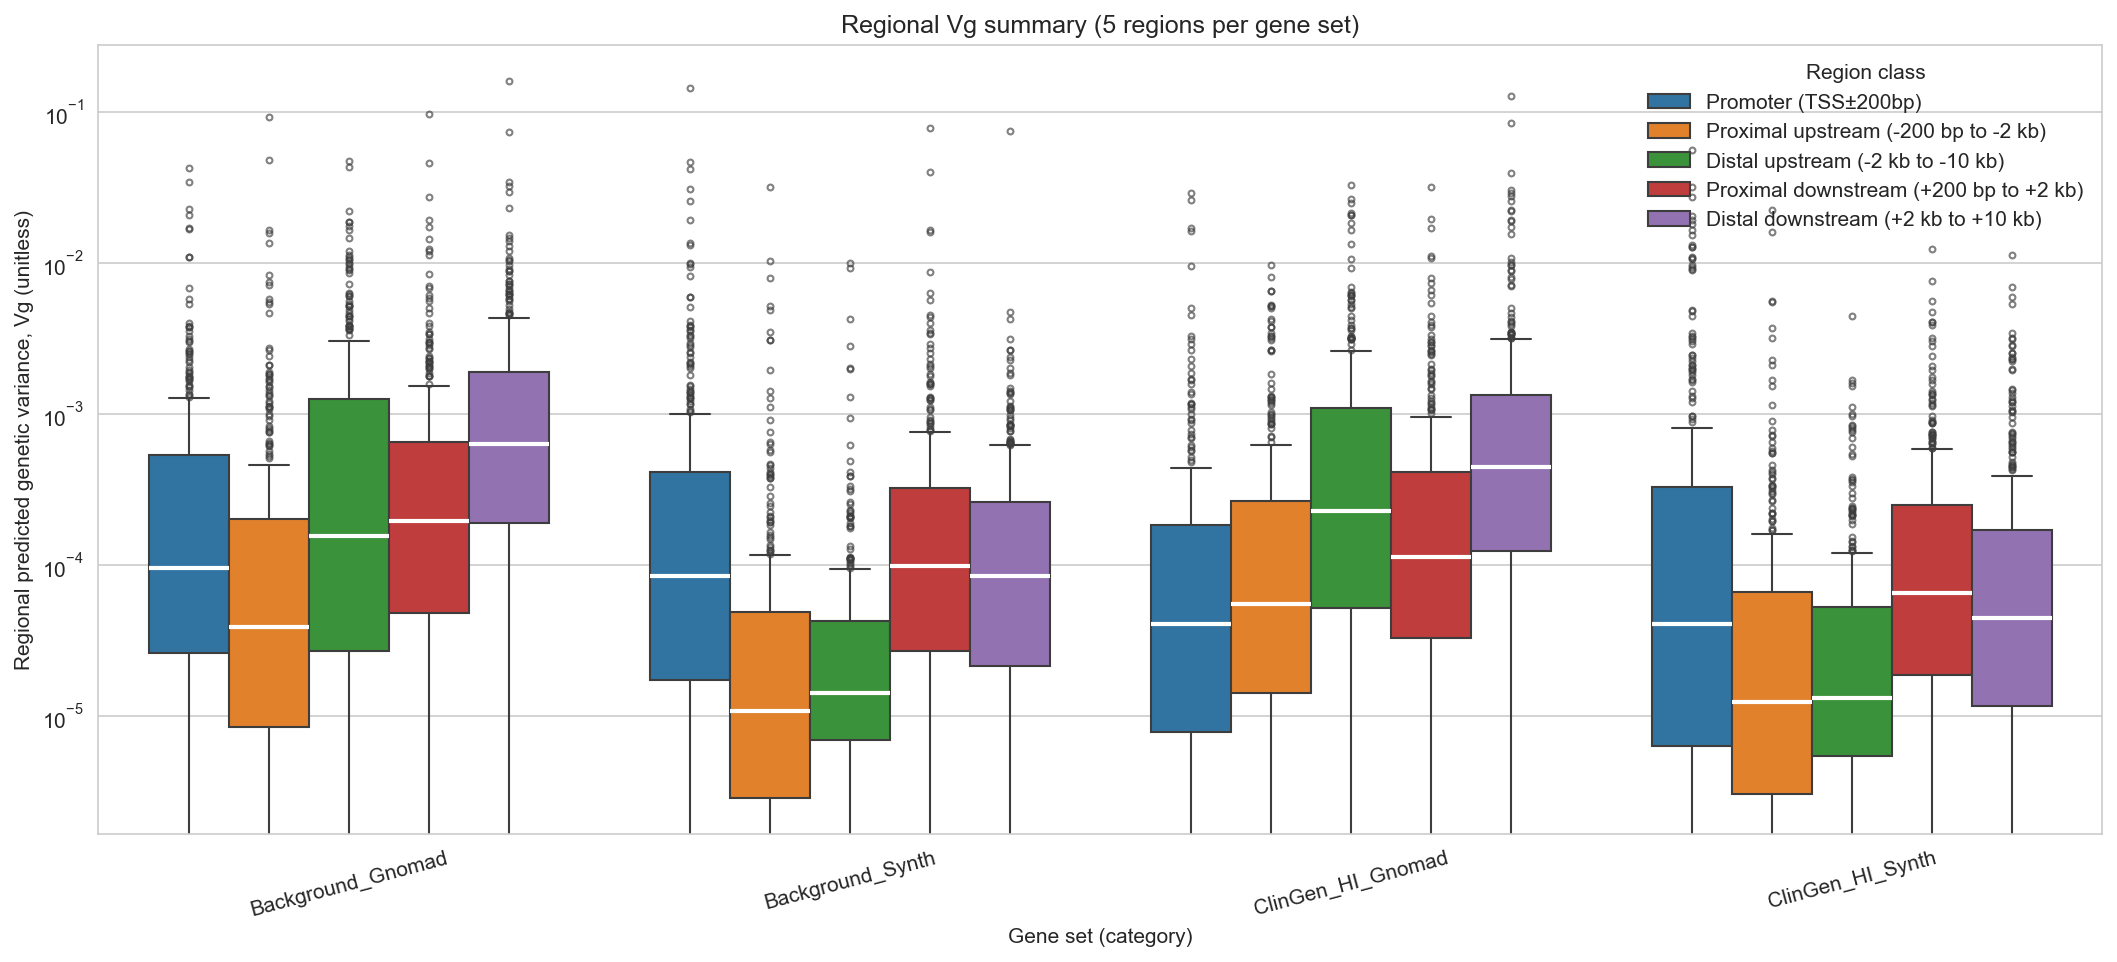

In [10]:
# 3) Regional Vg summary with 5 region boxes per gene set
region_5_long = plot_df.melt(
    id_vars=['source_label'],
    value_vars=[
        'vg_region_promoter_core',
        'vg_region_proximal_upstream',
        'vg_region_distal_upstream',
        'vg_region_down_proximal',
        'vg_region_down_distal',
    ],
    var_name='region_group',
    value_name='region_vg',
)
region_5_labels = {
    'vg_region_promoter_core': 'Promoter (TSS±200bp)',
    'vg_region_proximal_upstream': 'Proximal upstream (-200 bp to -2 kb)',
    'vg_region_distal_upstream': 'Distal upstream (-2 kb to -10 kb)',
    'vg_region_down_proximal': 'Proximal downstream (+200 bp to +2 kb)',
    'vg_region_down_distal': 'Distal downstream (+2 kb to +10 kb)',
}
region_5_order = [
    'Promoter (TSS±200bp)',
    'Proximal upstream (-200 bp to -2 kb)',
    'Distal upstream (-2 kb to -10 kb)',
    'Proximal downstream (+200 bp to +2 kb)',
    'Distal downstream (+2 kb to +10 kb)',
]
region_5_long['region_group'] = region_5_long['region_group'].map(region_5_labels)

with autosave('AF_Cutoff_Regional_Simplified_Boxplot'):
    fig, ax = plt.subplots(figsize=(14.0, 6.3), constrained_layout=True)
    sns.boxplot(
        data=region_5_long,
        x='source_label',
        y='region_vg',
        hue='region_group',
        order=source_label_order,
        hue_order=region_5_order,
        showfliers=True,
        flierprops={'marker': 'o', 'markersize': 2.8, 'alpha': 0.65},
        medianprops={'color': 'white', 'linewidth': 2.0},
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Regional predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Regional Vg summary (5 regions per gene set)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Region class', frameon=False)

# 3b. Regional Vg summary collapsed to Promoter / Upstream / Downstream

[save_plot] Saved: figuree_AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot_20022026_1129.pdf
[save_plot] Saved: figuree_AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot_20022026_1129.svg


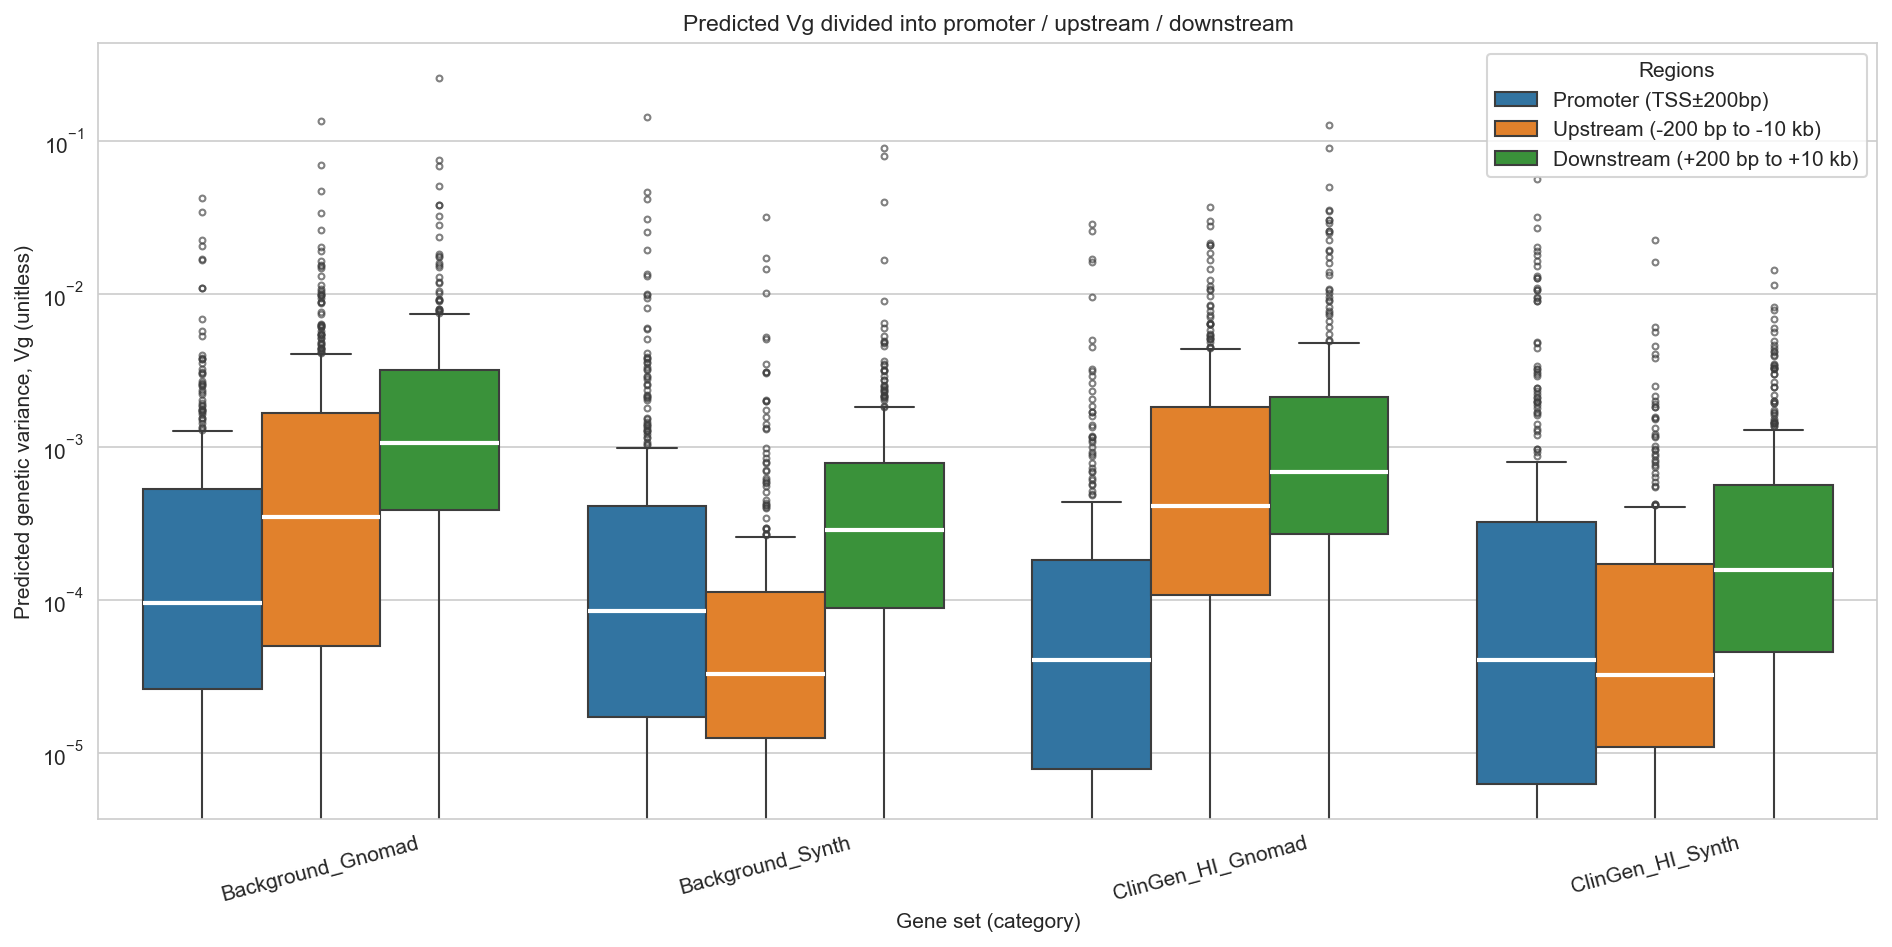

In [11]:
# 3b) Regional Vg summary collapsed to Promoter / Upstream / Downstream
region_3_df = plot_df.copy()
region_3_df['vg_upstream_total'] = region_3_df['vg_region_proximal_upstream'] + region_3_df['vg_region_distal_upstream']
region_3_df['vg_downstream_total'] = region_3_df['vg_region_down_proximal'] + region_3_df['vg_region_down_distal']

region_3_long = region_3_df.melt(
    id_vars=['source_label'],
    value_vars=[
        'vg_region_promoter_core',
        'vg_upstream_total',
        'vg_downstream_total',
    ],
    var_name='region_group',
    value_name='region_vg',
)

region_3_labels = {
    'vg_region_promoter_core': 'Promoter (TSS±200bp)',
    'vg_upstream_total': 'Upstream (-200 bp to -10 kb)',
    'vg_downstream_total': 'Downstream (+200 bp to +10 kb)',
}
region_3_order = [
    'Promoter (TSS±200bp)',
    'Upstream (-200 bp to -10 kb)',
    'Downstream (+200 bp to +10 kb)',
]
region_3_long['region_group'] = region_3_long['region_group'].map(region_3_labels)

with autosave('AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot'):
    fig, ax = plt.subplots(figsize=(12.5, 6.2), constrained_layout=True)
    sns.boxplot(
        data=region_3_long,
        x='source_label',
        y='region_vg',
        hue='region_group',
        order=source_label_order,
        hue_order=region_3_order,
        showfliers=True,
        flierprops={'marker': 'o', 'markersize': 2.8, 'alpha': 0.65},
        medianprops={'color': 'white', 'linewidth': 2.0},
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Predicted Vg divided into promoter / upstream / downstream', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Regions', frameon=True)

# 4. Rare fraction summary

[save_plot] Saved: figuree_AF_Cutoff_Rare_Fraction_of_Total_Vg_20022026_1129.pdf
[save_plot] Saved: figuree_AF_Cutoff_Rare_Fraction_of_Total_Vg_20022026_1129.svg
Plot 4 complete.


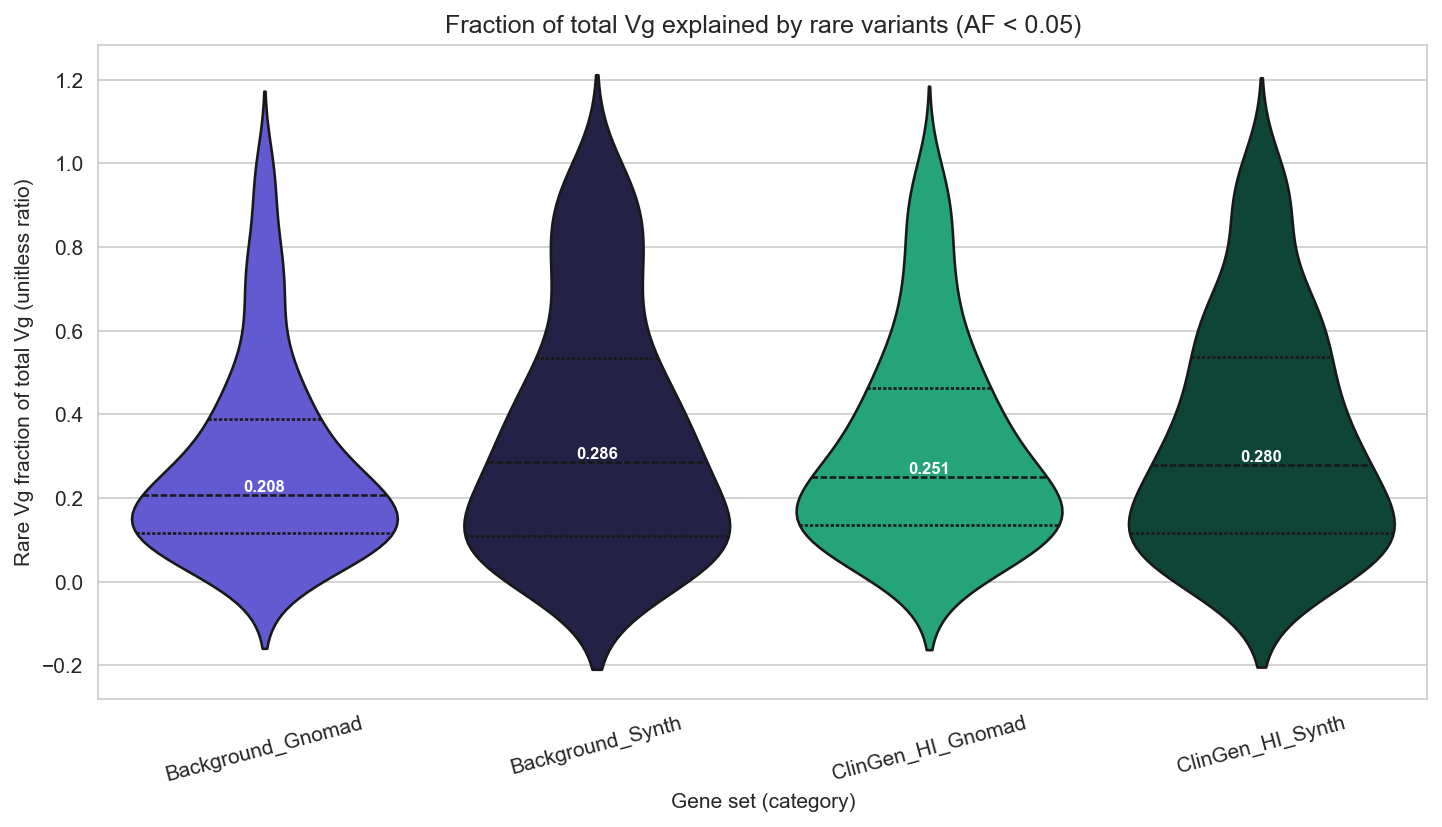

In [12]:
# 4) Rare fraction summary
with autosave('AF_Cutoff_Rare_Fraction_of_Total_Vg'):
    fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
    sns.violinplot(
        data=plot_df,
        x='source_label',
        y='vg_rare_fraction',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        legend=False,
        inner='quart',
        cut=2,
        bw_adjust=1.2,
        ax=ax,
    )
    annotate_medians(ax, plot_df, 'source_label', 'vg_rare_fraction', source_label_order, fmt='{:.3f}', text_color='white')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Rare Vg fraction of total Vg (unitless ratio)', fontsize=10)
    ax.set_title('Fraction of total Vg explained by rare variants (AF < 0.05)')
    ax.tick_params(axis='x', rotation=15)

print('Plot 4 complete.')